In [1]:
### Combiprecip 

In [2]:
import xarray as xr

In [3]:
Combiprecip_flowdepth = xr.open_dataset("/home/gespejogutierrez/Lisflood_climada/Zell_netcdfiles/Zell_2m_Combiprecip.nc")
Combiprecip_flowdepth 

<xarray.Dataset>
Dimensions:         (REFERENCE_TS: 11, y: 1500, x: 2500)
Coordinates:
  * REFERENCE_TS    (REFERENCE_TS) datetime64[ns] 2022-05-05T12:00:00 ... 202...
  * y               (y) float64 1.258e+06 1.258e+06 ... 1.255e+06 1.255e+06
  * x               (x) float64 2.702e+06 2.702e+06 ... 2.707e+06 2.707e+06
    spatial_ref     int64 ...
Data variables:
    water_depth     (REFERENCE_TS, y, x) float32 ...
    vel_x_c         (x, REFERENCE_TS, y) float32 ...
    vel_y_c         (y, REFERENCE_TS, x) float32 ...
    flux_x_c        (x, REFERENCE_TS, y) float32 ...
    flux_y_c        (y, REFERENCE_TS, x) float32 ...
    vel_mag         (x, REFERENCE_TS, y) float32 ...
    flux_mag        (x, REFERENCE_TS, y) float32 ...
    discharge_cell  (y, x, REFERENCE_TS) float32 ...
    speed_cell      (y, x, REFERENCE_TS) float32 ...
Attributes:
    Conventions:    CF-1.8
    source:         LISFLOOD single-member ASCII series, cell-centred on wate...
    deterministic:  true

In [4]:
from climada.entity import Exposures
from climada.entity.impact_funcs.base import ImpactFunc
from climada.entity.impact_funcs.impact_func_set import ImpactFuncSet
import numpy as np
import xarray as xr
from pyproj import Transformer
from scipy import sparse
import matplotlib.pyplot as plt
from climada.hazard import Hazard
from climada.engine import Impact
from climada.hazard.centroids.centr import Centroids

# --- INPUTS ---
HAZARD_ZELL = "/home/gespejogutierrez/Lisflood_climada/Zell_netcdfiles/Zell_2m_Combiprecip.nc"
VAR_NAME    = "water_depth"
GRID_EPSG   = 2056
WET_THRESH  = 0.01

# --- Read NetCDF ---
ds = xr.open_dataset(HAZARD_ZELL)
da = ds[VAR_NAME]

# --- Identify dimension names ---
# Expect y/x plus one "time-like" dim (here: REFERENCE_TS)
yx_dims = [d for d in da.dims if d.lower() in ("y", "x")]
if len(yx_dims) < 2:
    raise ValueError(f"Could not find x/y dims in {da.dims}")

# Choose time dim: the dim that is not x or y
time_dims = [d for d in da.dims if d not in ("y", "x")]
if len(time_dims) == 0:
    # 2D case: make a single event
    time_dim = "REFERENCE_TS"
    da = da.expand_dims({time_dim: [np.datetime64("1970-01-01T00:00:00")]})
elif len(time_dims) == 1:
    time_dim = time_dims[0]  # should be "REFERENCE_TS"
else:
    raise ValueError(f"More than one non-(x,y) dim found: {time_dims}. Please inspect da.dims.")

# --- Ensure order is (time, y, x) ---
da = da.transpose(time_dim, "y", "x")

# --- Grid coords ---
x = da["x"].values
y = da["y"].values
X, Y = np.meshgrid(x, y)  # (ny, nx)
ny, nx = Y.shape
n_cent = ny * nx

# --- Transform to WGS84 for CLIMADA centroids ---
transformer = Transformer.from_crs(GRID_EPSG, 4326, always_xy=True)
lon, lat = transformer.transform(X.ravel(order="C"), Y.ravel(order="C"))
cent = Centroids.from_lat_lon(lat=lat, lon=lon)

# --- Intensities (events x centroids) ---
arr = da.values  # (n_events, ny, nx)
arr = np.where(arr >= WET_THRESH, arr, 0.0)
intensity_2d = arr.reshape(arr.shape[0], n_cent)

# --- Build Hazard("FL") ---
haz = Hazard("FL")
haz.centroids = cent
haz.units = "m"

# --- Event metadata from timestamps ---
t = da[time_dim].values  # datetime64[ns]
n_events = intensity_2d.shape[0]

haz.event_id = np.arange(1, n_events + 1, dtype=int)

# event_name: keep time in name (safe string)
# Example: 2022-05-05T12:00
event_name = np.array(
    [np.datetime_as_string(tt, unit="m") for tt in t],
    dtype="U32"
)
haz.event_name = event_name

# haz.date must be int YYYYMMDD in CLIMADA (no time-of-day)
haz.date = np.array(
    [int(np.datetime_as_string(tt, unit="D").replace("-", "")) for tt in t],
    dtype=int
)

# frequency: for a deterministic time series, this is just a placeholder
haz.frequency = np.ones(n_events, dtype=float)

# assign intensity matrix (events x centroids)
haz.intensity = sparse.csr_matrix(intensity_2d)

# --- Sanity checks ---
print("time dim:", time_dim)
print("hazard events:", haz.size)
print("hazard intensity shape:", haz.intensity.shape)
print("centroids:", haz.centroids.size)
print("first event_name:", haz.event_name[0])
print("first date:", haz.date[0])


/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/dask/dataframe/_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 12.0.1. Please consider upgrading.
  warnings.warn(
/tmp/ipykernel_3080883/3368976766.py:53: DeprecatedWarning: from_lat_lon is deprecated. This method will be removed in a future version. Simply use the constructor instead.
  cent = Centroids.from_lat_lon(lat=lat, lon=lon)


time dim: REFERENCE_TS
hazard events: 11
hazard intensity shape: (11, 3750000)
centroids: 3750000
first event_name: 2022-05-05T12:00
first date: 20220505


In [5]:
###EXPOSURE 

In [6]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import shapely
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from datetime import datetime

# on climada_petals branch feature/networks until merged!
# on climada_python develop branch
from climada.util import coordinates as u_coords
from climada.entity.exposures.base import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import Impact
from climada.hazard.base import Hazard
from climada.util import lines_polys_handler as u_lp
from climada.util.api_client import Client

#from climada_petals.entity.exposures.openstreetmap import osm_dataloader as osm
from climada_petals.entity.exposures import osm_dataloader as osm
from climada.util import coordinates as u_coords
from climada.hazard.base import Hazard

In [7]:
import geopandas as gpd
import numpy as np
from climada.entity import Exposures

BULD_SHP = "/home/gespejogutierrez/Lisflood_climada/Data_for_process/geo_hwr_footp_tlm2023.shp"

gdf_build = gpd.read_file(BULD_SHP)
if gdf_build.empty:
    raise ValueError("No polygons found in the shapefile.")

# Ensure CRS is set (LV95/2056 typical in CH)
if gdf_build.crs is None:
    # set the CRS only if you KNOW the data are in LV95
    gdf_build = gdf_build.set_crs(2056)

# 1) Rename the active geometry column from 'geometry' -> 'geom_polygon_lv95'
gdf_build = gdf_build.rename_geometry("geom_polygon_lv95")
############### 

In [8]:
# 1) make inside-points as geometry (LV95)
gdf_build["geometry"] = gdf_build["geom_polygon_lv95"].centroid
gdf_build = gdf_build.set_geometry("geometry")

# 4) Reproject points to WGS84 for CLIMADA; also keep polygons in WGS84 if you want
gdf_build = gdf_build.to_crs(4326)
gdf_build["geom_polygon_wgs84"] = gdf_build["geom_polygon_lv95"].to_crs(4326)

In [9]:
gdf_build = gdf_build.set_geometry("geometry")
gdf_build

,id_def,objectid,geom_polygon_lv95,geometry,geom_polygon_wgs84
0,1936094,1936094.0,"POLYGON ((2559100.219 1119331.354, 2559097.819...",POINT (6.90852 46.22422),"POLYGON ((6.90855 46.22418, 6.90852 46.22416, ..."
1,1936249,1936249.0,"POLYGON ((2559322.635 1120047.691, 2559320.724...",POINT (6.91133 46.23066),"POLYGON ((6.91137 46.23064, 6.91135 46.23061, ..."
2,1936401,1936401.0,"POLYGON ((2559815.328 1120340.743, 2559812.163...",POINT (6.91771 46.23333),"POLYGON ((6.91773 46.23330, 6.91769 46.23328, ..."
3,1936562,1936562.0,"POLYGON ((2563105.573 1121841.543, 2563104.505...",POINT (6.96004 46.24690),"POLYGON ((6.96027 46.24699, 6.96025 46.24695, ..."
4,1936604,1936604.0,"POLYGON ((2562487.120 1119258.509, 2562486.155...",POINT (6.95244 46.22376),"POLYGON ((6.95245 46.22372, 6.95244 46.22372, ..."
...,...,...,...,...,...
2154736,1936056,1936056.0,"POLYGON ((2559263.941 1119311.501, 2559262.145...",POINT (6.91064 46.22405),"POLYGON ((6.91068 46.22401, 6.91065 46.22399, ..."
2154737,1936062,1936062.0,"POLYGON ((2559349.329 1119398.835, 2559346.684...",POINT (6.91167 46.22479),"POLYGON ((6.91178 46.22480, 6.91174 46.22477, ..."
2154738,1936067,1936067.0,"POLYGON ((2559460.084 1119554.328, 2559458.013...",POINT (6.91318 46.22622),"POLYGON ((6.91320 46.22621, 6.91317 46.22619, ..."
2154739,1936082,1936082.0,"POLYGON ((2559150.535 1119243.981, 2559149.085...",POINT (6.90918 46.22343),"POLYGON ((6.90921 46.22340, 6.90919 46.22338, ..."


In [35]:
### Roads

import geopandas as gpd
import xarray as xr
from shapely.geometry import box

roads = "/home/gespejogutierrez/Lisflood_climada/Data_for_process/geo_road_arcs.gpkg"
HAZARD_ZELL = "/home/gespejogutierrez/Lisflood_climada/Zell_netcdfiles/Zell_2m_COSMO_2022-05-05T12-00.nc"

# 1) domain bbox from NetCDF (LV95)
ds = xr.open_dataset(HAZARD_ZELL)
x = ds["x"].values
y = ds["y"].values
xmin, xmax = float(x.min()), float(x.max())
ymin, ymax = float(y.min()), float(y.max())

# optional buffer (meters)
buf = 200
domain_poly = box(xmin-buf, ymin-buf, xmax+buf, ymax+buf)

# 2) read roads
gdf_roads = gpd.read_file(roads)

# 3) ensure LV95 CRS
if gdf_roads.crs is None:
    gdf_roads = gdf_roads.set_crs(2056, allow_override=True)
else:
    gdf_roads = gdf_roads.to_crs(2056)

# 4) subset immediately (fast bbox subset)
gdf_roads = gdf_roads.cx[xmin-buf:xmax+buf, ymin-buf:ymax+buf].copy()

print("roads after subset:", len(gdf_roads))
gdf_roads.head()


roads after subset: 694


,id,objectid,uuid,datum_aenderung,datum_erstellung,erstellung_jahr,erstellung_monat,revision_jahr,revision_monat,grund_aenderung,...,y_begin,x_end,y_end,z_begin,z_end,z_min,z_max,nodeid1,nodeid2,geometry
13616,13611,13611,{D61342A7-4E76-4663-94A2-3D6A94BE7E7F},2016-02-02 10:31:08,2007-09-20,2002.0,NaN,2014.0,6.0,400,...,1256141.884,2702132.216,1256097.876,507.240,507.644,507.240,507.644,617674,617622,MULTILINESTRING Z ((2702147.659 1256141.884 50...
13618,13613,13613,{5D93EE21-78CF-4A26-BEFD-029F9B8DAD0E},2016-02-02 09:13:46,2007-09-20,2002.0,NaN,2014.0,6.0,400,...,1256900.286,2701939.566,1256749.481,499.548,501.449,499.548,501.525,616184,616892,MULTILINESTRING Z ((2701744.074 1256900.286 49...
13619,13614,13614,{628A665B-4633-42EC-875F-058382B69630},2016-02-02 10:31:08,2007-09-20,2002.0,NaN,2014.0,6.0,400,...,1256012.455,2702075.518,1255979.981,508.928,509.149,508.928,509.194,617477,617414,MULTILINESTRING Z ((2702092.129 1256012.455 50...
13620,13615,13615,{431AF2B0-EC63-48DF-AE89-E11FEB137D73},2016-02-02 10:31:08,2007-09-20,2002.0,NaN,2014.0,6.0,400,...,1255979.981,2702119.691,1255893.171,509.149,510.234,509.149,510.254,617414,617572,MULTILINESTRING Z ((2702075.518 1255979.981 50...
13621,13616,13616,{C79E22F8-79F1-4D03-A028-D87BC00CE3B1},2016-02-02 10:31:08,2007-09-20,2002.0,NaN,2014.0,6.0,400,...,1256454.010,2702209.289,1256369.576,504.435,504.767,504.435,504.899,618119,617910,MULTILINESTRING Z ((2702270.949 1256454.010 50...


In [36]:
# assume gdf_roads has geometry in LV95 (EPSG:2056)

# 1) rename the active geometry (LV95)
gdf_roads = gdf_roads.rename_geometry("geom_multipolygon_lv95")

# 2) create a WGS84 (EPSG:4326) geometry column
gdf_roads["geometry"] = (
    gdf_roads.set_geometry("geom_multipolygon_lv95")
             .to_crs(4326)
             .geometry
)

#  3) MAKE the WGS84 geometry the ACTIVE geometry
gdf_roads = gdf_roads.set_geometry("geometry")

#  4) FIX the CRS metadata to match the active geometry
gdf_roads = gdf_roads.set_crs(4326, allow_override=True)


In [10]:
def exposure_from_points(gdf, impf_dict):
    # TODO: check why 'FL' tag not taken when read in raster flood file
    exp_pnt = Exposures(gdf)
    exp_pnt.gdf[f'impf_FL'] = getattr(ImpFuncsCIFloodCH(), impf_dict['FL']).id
    exp_pnt.gdf['value'] = 1
    exp_pnt.set_lat_lon()
    exp_pnt.check()
    return exp_pnt
      
def exposure_from_lines(gdf, impf_dict, res, 
                        disagg_met=u_lp.DisaggMethod.FIX, disagg_val=None):
    exp_line = Exposures(gdf)
    if not disagg_val:
        disagg_val = res
    exp_pnt = u_lp.exp_geom_to_pnt(exp_line, res=res, to_meters=True, 
                                   disagg_met=disagg_met, disagg_val=disagg_val)  
    exp_pnt.gdf[f'impf_FL'] = getattr(ImpFuncsCIFloodCH(), impf_dict['FL']).id
    exp_pnt.set_lat_lon()
    exp_pnt.check() 
    return exp_pnt

In [11]:
# some impact functions we have used in the past.
class ImpFuncsCIFloodCH():

    def __init__(self):
        self.tag = 'FL'
        self.building =self.regional_cal()
        self.road = self.regional_cal()

    def regional_cal(self):
        step_impf = ImpactFunc()
        step_impf.id = 1
        step_impf.haz_type = 'FL'
        step_impf.name = 'regional calibration'
        step_impf.intensity_unit = ''
        step_impf.intensity = np.array([0,0.04,1,2,3,4])
        step_impf.mdd = np.array([0,0.03,0.13,0.29,0.48,0.76])
        step_impf.paa = np.sort(np.linspace(1, 1, num=6))
        step_impf.check()
        return step_impf

In [12]:
exp_building = exposure_from_points(gdf_build, {'FL': 'building'})

In [37]:
##########
import copy
exp_rd = exposure_from_lines(copy.deepcopy(gdf_roads), {'FL': 'road'}, res=500)

In [13]:
exp_building.gdf

,id_def,objectid,geom_polygon_lv95,geometry,geom_polygon_wgs84,impf_FL,value,latitude,longitude
0,1936094,1936094.0,"POLYGON ((2559100.219 1119331.354, 2559097.819...",POINT (6.90852 46.22422),"POLYGON ((6.90855 46.22418, 6.90852 46.22416, ...",1,1,46.224222,6.908523
1,1936249,1936249.0,"POLYGON ((2559322.635 1120047.691, 2559320.724...",POINT (6.91133 46.23066),"POLYGON ((6.91137 46.23064, 6.91135 46.23061, ...",1,1,46.230656,6.911330
2,1936401,1936401.0,"POLYGON ((2559815.328 1120340.743, 2559812.163...",POINT (6.91771 46.23333),"POLYGON ((6.91773 46.23330, 6.91769 46.23328, ...",1,1,46.233327,6.917705
3,1936562,1936562.0,"POLYGON ((2563105.573 1121841.543, 2563104.505...",POINT (6.96004 46.24690),"POLYGON ((6.96027 46.24699, 6.96025 46.24695, ...",1,1,46.246902,6.960043
4,1936604,1936604.0,"POLYGON ((2562487.120 1119258.509, 2562486.155...",POINT (6.95244 46.22376),"POLYGON ((6.95245 46.22372, 6.95244 46.22372, ...",1,1,46.223755,6.952437
...,...,...,...,...,...,...,...,...,...
2154736,1936056,1936056.0,"POLYGON ((2559263.941 1119311.501, 2559262.145...",POINT (6.91064 46.22405),"POLYGON ((6.91068 46.22401, 6.91065 46.22399, ...",1,1,46.224048,6.910644
2154737,1936062,1936062.0,"POLYGON ((2559349.329 1119398.835, 2559346.684...",POINT (6.91167 46.22479),"POLYGON ((6.91178 46.22480, 6.91174 46.22477, ...",1,1,46.224792,6.911665
2154738,1936067,1936067.0,"POLYGON ((2559460.084 1119554.328, 2559458.013...",POINT (6.91318 46.22622),"POLYGON ((6.91320 46.22621, 6.91317 46.22619, ...",1,1,46.226225,6.913176
2154739,1936082,1936082.0,"POLYGON ((2559150.535 1119243.981, 2559149.085...",POINT (6.90918 46.22343),"POLYGON ((6.90921 46.22340, 6.90919 46.22338, ...",1,1,46.223428,6.909178


In [14]:
def make_impfset(imp_class):
    impfset = ImpactFuncSet()
    for attribute in set(imp_class.__dict__.keys()).difference({'tag'}):
        impfset.append(getattr(imp_class, attribute))
    return impfset

In [15]:
impf_set_fl = make_impfset(ImpFuncsCIFloodCH())

<Axes: title={'center': 'FL 1: regional calibration'}, xlabel='Intensity ()', ylabel='Impact (%)'>

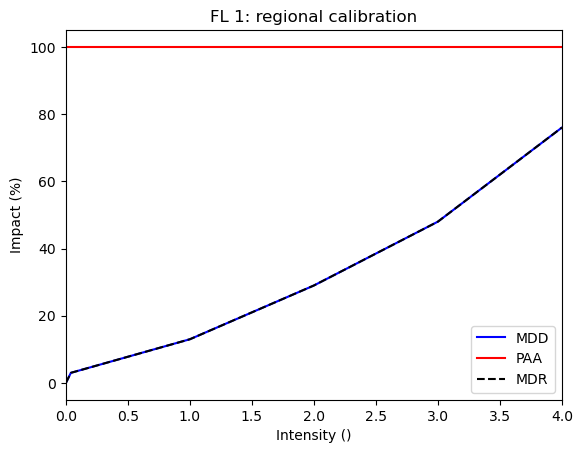

In [16]:
impf_set_fl.plot()

In [17]:
### IMPACT 
imp_fl_building = Impact()
imp_fl_building.calc(exp_building, impf_set_fl, haz,save_mat=True)

2025-12-22 14:06:28,341 - climada.engine.impact - WARNING - The use of Impact().calc() is deprecated. Use ImpactCalc().impact() instead.
2025-12-22 14:06:39,360 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 100km for 1223483 coordinates.


In [39]:
### IMPACT 
imp_fl_road = Impact()
imp_fl_road.calc(exp_rd, impf_set_fl, haz,save_mat=True)

2025-12-22 14:31:21,756 - climada.engine.impact - WARNING - The use of Impact().calc() is deprecated. Use ImpactCalc().impact() instead.


In [19]:
import os
import socket
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from pyproj import Transformer

def plot_impact_polygons_timewindow_wms_3857(
    imp,
    exp,
    start_ts,
    end_ts,
    xmin_2056, xmax_2056, ymin_2056, ymax_2056,
    impact_thresh=0.03,
    geom_col="geom_polygon_lv95",
    save_dir="/storage/homefs/ge24z347/Liestal_event/ZELL_PLOTS/Zell_2m_Combiprecip",
    dpi=200,
    timeout_s=240,
    wms_retries=4,
    wms_sleep_s=2,
    layer="ch.swisstopo.swisstlm3d-karte-grau",
):
    """
    3857 basemap + polygons on top.
    - input extent is EPSG:2056 meters
    - internally converts extent to EPSG:3857 for ax.set_extent
    - polygons are converted to EPSG:3857 for plotting
    """

    os.makedirs(save_dir, exist_ok=True)

    # Make WMS less likely to timeout
    socket.setdefaulttimeout(timeout_s)

    start = np.datetime64(start_ts)
    end   = np.datetime64(end_ts)

    # --- event timestamps from imp.event_name if possible ---
    ev_times = None
    if hasattr(imp, "event_name") and imp.event_name is not None:
        try:
            ev_times = np.array([np.datetime64(s) for s in imp.event_name])
        except Exception:
            ev_times = None
    if ev_times is None:
        ev_times = np.array([np.datetime64("1970-01-01T00:00") + np.timedelta64(i, "h")
                             for i in range(imp.imp_mat.shape[0])])

    idx = np.where((ev_times >= start) & (ev_times <= end))[0]
    if idx.size == 0:
        raise ValueError(f"No events found between {start_ts} and {end_ts}")

    # --- polygons: activate geometry column ---
    gdf = exp.gdf.copy()
    if geom_col not in gdf.columns:
        raise ValueError(f"'{geom_col}' not in exp.gdf. Example cols: {list(gdf.columns)[:25]}")
    gdf = gdf.set_geometry(geom_col)

    if gdf.crs is None:
        raise ValueError("exp.gdf.crs is None. Set it to the correct CRS (usually 2056 or 4326).")

    # If CRS not 2056, project to 2056 first (so your Swiss-meter extent makes sense)
    if gdf.crs.to_epsg() != 2056:
        gdf_2056 = gdf.to_crs(epsg=2056)
    else:
        gdf_2056 = gdf

    # Then project polygons to 3857 for plotting on 3857 axis
    gdf_3857 = gdf_2056.to_crs(epsg=3857)

    # --- extent: 2056 -> 3857 ---
    to_3857 = Transformer.from_crs(2056, 3857, always_xy=True)
    xmin_3857, ymin_3857 = to_3857.transform(xmin_2056, ymin_2056)
    xmax_3857, ymax_3857 = to_3857.transform(xmax_2056, ymax_2056)

    # --- impact array ---
    imp_arr = imp.imp_mat.toarray()
    if imp_arr.shape[1] != len(gdf_3857):
        raise ValueError(
            f"Length mismatch: impact has {imp_arr.shape[1]} exposures, polygons have {len(gdf_3857)} rows."
        )

    # --- colormap ---
    bounds = [impact_thresh, 0.13, 0.29, 0.48, 0.76, 1.00]
    colors = ["#ffffb2", "#fed976", "#feb24c", "#fd8d3c", "#f03b20"]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N, clip=True)

    merc = ccrs.epsg(3857)

    for k, event_idx in enumerate(idx):
        vals = imp_arr[event_idx]

        gplot = gdf_3857.copy()
        gplot["impact"] = vals
        gplot = gplot[np.isfinite(gplot["impact"])]
        gplot = gplot[gplot["impact"] >= impact_thresh]

        fig = plt.figure(figsize=(10, 10), dpi=dpi)
        ax = plt.axes(projection=merc)
        ax.set_extent([xmin_3857, xmax_3857, ymin_3857, ymax_3857], crs=merc)
        ax.set_aspect("equal")

        # --- Swisstopo WMS background (same call, but on 3857 axis) ---
        ok = False
        last_err = None
        for r in range(wms_retries):
            try:
                ax.add_wms("https://wms.geo.admin.ch/?", layers=layer)
                ok = True
                break
            except Exception as e:
                last_err = e
                time.sleep(wms_sleep_s)

        if not ok:
            print(f"[WMS failed after {wms_retries} retries] {type(last_err).__name__}: {last_err}")

        # --- polygons on top (already 3857) ---
        if len(gplot) > 0:
            gplot.plot(
                column="impact",
                ax=ax,
                cmap=cmap,
                norm=norm,
                edgecolor="none",
                transform=merc,
                zorder=5
            )

        # colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm._A = []
        cb = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.85, ticks=bounds)
        cb.set_label("Impact (damage fraction)")

        t_now = np.datetime_as_string(ev_times[event_idx], unit="m")
        t0 = np.datetime_as_string(start, unit="m")
        t1 = np.datetime_as_string(end, unit="m")
        ax.set_title(f"Impact on buildings | timestep: {t_now}")

        plt.tight_layout()
        safe_t = t_now.replace(":", "-")
        fn = os.path.join(save_dir, f"impact_polygons_{k:03d}_{safe_t}.png")
        plt.savefig(fn, dpi=dpi)
        plt.close(fig)

    print(f"Saved {len(idx)} PNGs to: {save_dir}")


In [20]:
plot_impact_polygons_timewindow_wms_3857(
    imp=imp_fl_building,
    exp=exp_building,
    start_ts="2022-05-05T12:00:00.000000000",
    end_ts="2022-05-05T22:00:00.000000000",
    xmin_2056=2703600, xmax_2056=2704800,
    ymin_2056=1255250, ymax_2056=1256770,
    impact_thresh=0.01,
    geom_col="geom_polygon_lv95",
    save_dir="/home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots"
)

/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer_v2_0.oereb" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.panzerverschiebungsrouten" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/

Saved 11 PNGs to: /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots


In [ ]:
### Plotting the impact in the roads 
imp_fl_road

In [40]:
import numpy as np
import pandas as pd

# --- Convert impact matrix to array ---
imp_array = imp_fl_road.imp_mat.toarray()
n_time, n_exposures = imp_array.shape
print(f"Impact matrix: {n_time} time steps × {n_exposures:,} exposures")

# --- Prepare exposure subset ---
#  You can include more columns here if you want (e.g., 'geometry', 'name', etc.)
exp_df = exp_rd.gdf[["id", "objectid", "geometry_orig", "geom_multipolygon_lv95"]].copy()
assert len(exp_df) == n_exposures, "Exposure and impact dimensions do not match!"

# --- Precompute grouping index ---
group_keys = exp_df[["id", "objectid"]].reset_index(drop=True)
group_index = group_keys.groupby(["id", "objectid"]).ngroup().to_numpy()  # flat numeric group index

# --- Build lookup table for unique groups and geometries ---
#  You can also add more columns here if needed (keep only unique geometries)
group_info = (
    exp_df.groupby(["id", "objectid"], as_index=False)
    .agg({"geometry_orig": "first",
          "geom_multipolygon_lv95": "first"})  # keep first geometry per unique id/objectid
    .reset_index(drop=True)
)

# --- Initialize dict for time-step results ---
m_rdimpact = {}

# --- Aggregate per time step ---
for t in range(n_time):
    impacts = imp_array[t, :]

    # Build a DataFrame directly from arrays (avoids index misalignment)
    df_tmp = pd.DataFrame({"group": group_index, "impact": impacts})

    # Aggregate by unique group
    df_grouped = df_tmp.groupby("group", as_index=False)["impact"].mean()

    # Merge with geometry + identifiers
    df_t = pd.concat([group_info, df_grouped["impact"]], axis=1)

    # Optionally scale by 500
    df_t["impact"] = df_t["impact"] / 500

    #  Keep a copy of geometry column as active GeoSeries later for plotting
    df_t["geometry"] = df_t["geom_multipolygon_lv95"]

    # Store per time step
    m_rdimpact[t] = df_t

    print(f"Time step {t}: {len(df_t):,} rows")

print(f"\n Created {len(m_rdimpact)} time-step DataFrames.")
print(f"Example key: {list(m_rdimpact.keys())[0]}")
print(m_rdimpact[0].head())


Impact matrix: 11 time steps × 698 exposures
Time step 0: 694 rows
Time step 1: 694 rows
Time step 2: 694 rows
Time step 3: 694 rows
Time step 4: 694 rows
Time step 5: 694 rows
Time step 6: 694 rows
Time step 7: 694 rows
Time step 8: 694 rows
Time step 9: 694 rows
Time step 10: 694 rows

 Created 11 time-step DataFrames.
Example key: 0
      id  objectid                                      geometry_orig  \
0  13611     13611  MULTILINESTRING Z ((8.79305 47.44814 507.24000...   
1  13613     13613  MULTILINESTRING Z ((8.78788 47.45502 499.54800...   
2  13614     13614  MULTILINESTRING Z ((8.79229 47.44698 508.92800...   
3  13615     13615  MULTILINESTRING Z ((8.79206 47.44669 509.14900...   
4  13616     13616  MULTILINESTRING Z ((8.79476 47.45092 504.43500...   

                              geom_multipolygon_lv95  impact  \
0  MULTILINESTRING Z ((2702147.659 1256141.884 50...     0.0   
1  MULTILINESTRING Z ((2701744.074 1256900.286 49...     0.0   
2  MULTILINESTRING Z ((2702092.

/tmp/ipykernel_3080883/351856320.py:47: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  df_t["geometry"] = df_t["geom_multipolygon_lv95"]
/tmp/ipykernel_3080883/351856320.py:47: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  df_t["geom

In [41]:
m_rdimpact [10]

,id,objectid,geometry_orig,geom_multipolygon_lv95,impact,geometry
0,13611,13611,MULTILINESTRING Z ((8.79305 47.44814 507.24000...,MULTILINESTRING Z ((2702147.659 1256141.884 50...,0.052917,MULTILINESTRING Z ((2702147.659 1256141.884 50...
1,13613,13613,MULTILINESTRING Z ((8.78788 47.45502 499.54800...,MULTILINESTRING Z ((2701744.074 1256900.286 49...,0.737320,MULTILINESTRING Z ((2701744.074 1256900.286 49...
2,13614,13614,MULTILINESTRING Z ((8.79229 47.44698 508.92800...,MULTILINESTRING Z ((2702092.129 1256012.455 50...,0.038958,MULTILINESTRING Z ((2702092.129 1256012.455 50...
3,13615,13615,MULTILINESTRING Z ((8.79206 47.44669 509.14900...,MULTILINESTRING Z ((2702075.518 1255979.981 50...,0.000000,MULTILINESTRING Z ((2702075.518 1255979.981 50...
4,13616,13616,MULTILINESTRING Z ((8.79476 47.45092 504.43500...,MULTILINESTRING Z ((2702270.949 1256454.010 50...,0.067188,MULTILINESTRING Z ((2702270.949 1256454.010 50...
...,...,...,...,...,...,...
689,786434,786434,MULTILINESTRING Z ((8.84630 47.46318 692.26100...,MULTILINESTRING Z ((2706132.664 1257885.208 69...,0.000000,MULTILINESTRING Z ((2706132.664 1257885.208 69...
690,786435,786435,MULTILINESTRING Z ((8.84926 47.46423 706.87800...,MULTILINESTRING Z ((2706353.818 1258005.820 70...,0.032604,MULTILINESTRING Z ((2706353.818 1258005.820 70...
691,788918,788918,MULTILINESTRING Z ((8.81201 47.45718 627.98200...,MULTILINESTRING Z ((2703559.826 1257171.991 62...,0.009000,MULTILINESTRING Z ((2703559.826 1257171.991 62...
692,800845,800845,MULTILINESTRING Z ((8.82424 47.43948 535.36400...,MULTILINESTRING Z ((2704516.298 1255221.278 53...,0.000000,MULTILINESTRING Z ((2704516.298 1255221.278 53...


In [44]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import force_2d
from PIL import Image
import requests
from io import BytesIO
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from datetime import datetime, timedelta


def get_swisstopo_background_image(xmin, xmax, ymin, ymax, resolution_m=2,
                                   layer="ch.swisstopo.swisstlm3d-karte-grau"):
    width_px = int((xmax - xmin) / resolution_m)
    height_px = int((ymax - ymin) / resolution_m)
    bbox = f"{xmin},{ymin},{xmax},{ymax}"
    params = {
        "SERVICE": "WMS",
        "REQUEST": "GetMap",
        "VERSION": "1.3.0",
        "LAYERS": layer,
        "BBOX": bbox,
        "CRS": "EPSG:2056",
        "WIDTH": width_px,
        "HEIGHT": height_px,
        "FORMAT": "image/png",
        "TRANSPARENT": "TRUE"
    }
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept": "image/png,image/*,*/*;q=0.8"
    }

    response = requests.get("https://wms.geo.admin.ch/", params=params, headers=headers)
    if response.status_code == 200:
        print(f"✔ Swisstopo WMS fetched ({width_px}×{height_px}px)")
        return Image.open(BytesIO(response.content))
    else:
        print(f"Failed to fetch WMS: HTTP {response.status_code}")
        print(f"URL: {response.url}")
        return None


def plot_road_impacts_wms(
    m_rdimpact: dict,
    *,
    start_key=0,
    threshold=0.03,
    outdir=None,
    dpi=300,
    xmin=2673000, xmax=2677000,
    ymin=1265500, ymax=1268000,
    title_color="black",
    initial_time_str="2022-05-05T12:00:00"
):
    """
    Plot road impacts for timesteps ≥ start_key with Swisstopo WMS background.
    Title is the actual timestamp:
      initial_time_str + (key-start_key) hours
    """

    # base time
    try:
        base_time = datetime.fromisoformat(initial_time_str)
    except ValueError:
        raise ValueError("Please provide initial_time_str in ISO format, e.g., '2022-05-05T12:00:00'")

    # background
    bg_img = get_swisstopo_background_image(
        xmin, xmax, ymin, ymax,
        resolution_m=1.5,
        layer="ch.swisstopo.swisstlm3d-karte-grau"
    )

    # discrete bounds
    bounds = [0.03, 0.13, 0.29, 0.48, 0.76, 1.0]
    cmap = cm.get_cmap("YlOrRd", len(bounds) - 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    for key, roads_gdf in m_rdimpact.items():
        if key < start_key:
            continue

        print(f"🛣️ Plotting timestep {key}...")

        roads_gdf = gpd.GeoDataFrame(roads_gdf, geometry="geom_multipolygon_lv95", crs="EPSG:2056")

        # Drop Z if present
        try:
            roads_gdf["geom_multipolygon_lv95"] = roads_gdf["geom_multipolygon_lv95"].apply(force_2d)
        except Exception:
            pass

        roads_gdf = roads_gdf.set_geometry("geom_multipolygon_lv95")

        # Filter impacts
        roads_gdf = roads_gdf[roads_gdf["impact"] >= threshold]
        if roads_gdf.empty:
            print(f" No impacts ≥ {threshold} for timestep {key}")
            continue

        # --- TITLE: real timestamp (no "+ lead time") ---
        lead_hours = int(key - start_key)
        title_dt = base_time + timedelta(hours=lead_hours)
        title_time = title_dt.strftime("%Y-%m-%dT%H:%M:%S")

        fig, ax = plt.subplots(figsize=(10, 10), dpi=dpi)

        if bg_img:
            ax.imshow(bg_img, extent=[xmin, xmax, ymin, ymax], origin="upper", zorder=0)

        roads_gdf.plot(
            ax=ax,
            column="impact",
            cmap=cmap,
            linewidth=1.5,
            legend=False,
            zorder=5,
            norm=norm
        )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(title_time, fontsize=14, color=title_color)
        ax.axis("off")

        # colorbar
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, boundaries=bounds, fraction=0.036, pad=0.02)
        cbar.set_label("damage fraction", fontsize=12)
        cbar.ax.tick_params(labelsize=10)
        cbar.set_ticks(bounds)
        cbar.ax.set_yticklabels([f"{b:.2f}" for b in bounds])
        cbar.outline.set_linewidth(0.5)

        if outdir:
            os.makedirs(outdir, exist_ok=True)
            fn = os.path.join(outdir, f"road_impact_wms_{title_time}.png")
            plt.savefig(fn, dpi=dpi, bbox_inches="tight", transparent=True)
            print(f"✔ Saved {fn}")
        else:
            plt.show()

        plt.close(fig)


In [47]:
plot_road_impacts_wms(
    m_rdimpact,
    start_key=0,
    threshold=0.03,
    outdir="/home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots",
    dpi=300,
    xmin=2702857, xmax=2705907,    
    ymin=1254992, ymax=1257996,    
    title_color="black",
    initial_time_str="2022-05-05T12:00:00"
)

✔ Swisstopo WMS fetched (2033×2002px)
🛣️ Plotting timestep 0...
 No impacts ≥ 0.03 for timestep 0
🛣️ Plotting timestep 1...
 No impacts ≥ 0.03 for timestep 1
🛣️ Plotting timestep 2...
 No impacts ≥ 0.03 for timestep 2
🛣️ Plotting timestep 3...
 No impacts ≥ 0.03 for timestep 3
🛣️ Plotting timestep 4...
 No impacts ≥ 0.03 for timestep 4
🛣️ Plotting timestep 5...


/tmp/ipykernel_3080883/181091923.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlOrRd", len(bounds) - 1)


✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/road_impact_wms_2022-05-05T17:00:00.png
🛣️ Plotting timestep 6...
✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/road_impact_wms_2022-05-05T18:00:00.png
🛣️ Plotting timestep 7...
✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/road_impact_wms_2022-05-05T19:00:00.png
🛣️ Plotting timestep 8...
✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/road_impact_wms_2022-05-05T20:00:00.png
🛣️ Plotting timestep 9...
✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/road_impact_wms_2022-05-05T21:00:00.png
🛣️ Plotting timestep 10...
✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/road_impact_wms_2022-05-05T22:00:00.png


In [21]:
### How many are affected? 

In [22]:
import numpy as np
import pandas as pd
import geopandas as gpd


def impact_to_gdf_long(
    imp,
    time_key=None,              # e.g. "ZELL_2022-05-05T12:00" (optional)
    gdf_build=None,             # must contain 'geom_polygon_lv95' (and ideally 'exp_id')
    exp_id_col="exp_id",
    geom_col="geom_polygon_lv95",
    event_name_prefix="ens",    # if imp.event_name missing, fallback to ens0, ens1, ...
    keep_point_geometry=False,  # add exposure point geometry (WGS84) as extra column
):
    """
    LONG GeoDataFrame for ONE Impact object (one forecast time).

    Output columns (typical):
      - geometry      : building polygons from gdf_build[geom_col] (EPSG:2056)
      - lat, lon      : CLIMADA exposure coordinates (EPSG:4326)
      - exp_id        : exposure id (from gdf_build if present, else generated)
      - event_id      : 1..n_events
      - event_name    : CLIMADA event name (if available) or ens0, ens1, ...
      - impact        : impact value for (event, exposure)
      - time_key      : your passed key (optional)
      - run_datetime  : parsed datetime from time_key if possible (optional)
    """

    if gdf_build is None:
        raise ValueError("gdf_build (with polygons) must be provided.")
    if geom_col not in gdf_build.columns:
        raise ValueError(f"gdf_build must have a '{geom_col}' column.")

    n_events, n_exp = imp.imp_mat.shape

    # Ensure same number of exposures as polygons table
    if len(gdf_build) != n_exp:
        raise ValueError(
            f"gdf_build has {len(gdf_build)} rows but impact has {n_exp} exposures. "
            "They must match and be in the same order."
        )

    # Base table from polygons
    base = gdf_build.copy()

    # Ensure exp_id exists (stable join key)
    if exp_id_col not in base.columns:
        base[exp_id_col] = np.arange(n_exp, dtype=int)

    # Set polygon geometry (LV95)
    base = gpd.GeoDataFrame(base, geometry=geom_col, crs="EPSG:2056")

    # Add exposure coords (WGS84)
    lats = imp.coord_exp[:, 0]
    lons = imp.coord_exp[:, 1]
    if len(lats) != n_exp:
        raise ValueError("Number of coord_exp points does not match number of exposures.")

    base["lat"] = lats
    base["lon"] = lons

    # Optional: keep exposure point geometry as extra column
    if keep_point_geometry:
        base["geometry_wgs84_pt"] = gpd.points_from_xy(base["lon"], base["lat"], crs="EPSG:4326")

    # Event labels
    if hasattr(imp, "event_name") and imp.event_name is not None and len(imp.event_name) == n_events:
        event_names = list(imp.event_name)
    else:
        event_names = [f"{event_name_prefix}{i}" for i in range(n_events)]

    # Convert sparse -> COO for efficient long format
    mat = imp.imp_mat.tocoo()

    # Create long rows ONLY where impact is non-zero
    df_long = pd.DataFrame({
        "event_idx": mat.row.astype(int),       # 0-based
        "exp_idx":   mat.col.astype(int),       # 0-based
        "impact":    mat.data.astype(float),
    })

    # Map event fields
    df_long["event_id"] = df_long["event_idx"] + 1
    df_long["event_name"] = [event_names[i] for i in df_long["event_idx"].values]

    # Attach exposure ids and coordinates by exp_idx
    df_long[exp_id_col] = base[exp_id_col].values[df_long["exp_idx"].values]
    df_long["lat"] = base["lat"].values[df_long["exp_idx"].values]
    df_long["lon"] = base["lon"].values[df_long["exp_idx"].values]

    # Optional time info
    if time_key is not None:
        df_long["time_key"] = str(time_key)
        # try to parse datetime from key like "ZELL_2022-05-05T12:00"
        try:
            dt_str = str(time_key).split("_", 1)[-1]
            df_long["run_datetime"] = pd.to_datetime(dt_str)
        except Exception:
            pass

    # Now build GeoDataFrame by joining polygons from base using exp_idx
    # We avoid a merge by using direct indexing (fast and preserves order)
    geom = base.geometry.values[df_long["exp_idx"].values]
    gdf_long = gpd.GeoDataFrame(df_long, geometry=geom, crs="EPSG:2056")

    # Clean helper cols if you don't want them
    gdf_long = gdf_long.drop(columns=["event_idx", "exp_idx"])

    return gdf_long


In [23]:
gdf_long = impact_to_gdf_long(
    imp_fl_building,
    time_key=None,            # or put a string like "ZELL_2022-05-05T15:00"
    gdf_build=gdf_build,
    exp_id_col="exp_id",
    geom_col="geom_polygon_lv95",
    keep_point_geometry=False
)


In [24]:
## Interpolation inverse: water depth based on the impact calculated of climada 
import numpy as np

# original impact function
INTENSITY = np.array([0, 0.04, 1, 2, 3, 4])
MDD       = np.array([0, 0.03, 0.13, 0.29, 0.48, 0.76])

def impact_to_water_depth(impact_values):
    """
    Convert impact (MDD) values to water depth using inverse interpolation.
    """
    # clip to valid range to avoid extrapolation issues
    impact_clipped = np.clip(impact_values, MDD.min(), MDD.max())

    # inverse interpolation: mdd -> intensity
    water_depth = np.interp(
        impact_clipped,
        MDD,          # y-axis
        INTENSITY     # x-axis
    )
    return water_depth


In [25]:
gdf_long["water_depth_m"] = impact_to_water_depth(
    gdf_long["impact"].values
)

In [26]:
gdf_long

,impact,event_id,event_name,exp_id,lat,lon,geometry,water_depth_m
0,0.0150,6,2022-05-05T17:00,1520,47.500642,8.066584,"POLYGON ((2647316.695 1261287.974, 2647314.991...",0.020
1,0.0150,6,2022-05-05T17:00,1543,47.504026,7.951927,"POLYGON ((2638675.732 1261598.617, 2638671.451...",0.020
2,0.1564,6,2022-05-05T17:00,1599,46.625684,8.830246,"POLYGON ((2706579.093 1164770.111, 2706577.382...",1.165
3,0.0425,6,2022-05-05T17:00,1601,46.626702,8.836787,"POLYGON ((2707072.279 1164896.303, 2707075.068...",0.160
4,0.0150,6,2022-05-05T17:00,1662,47.509702,8.594190,"POLYGON ((2687053.366 1262744.158, 2687050.237...",0.020
...,...,...,...,...,...,...,...,...
852839,0.6508,11,2022-05-05T22:00,2153366,47.587059,8.290264,"POLYGON ((2664059.990 1271066.320, 2664060.303...",3.610
852840,0.6508,11,2022-05-05T22:00,2153369,47.550714,8.220761,"POLYGON ((2658878.432 1266960.548, 2658876.476...",3.610
852841,0.6508,11,2022-05-05T22:00,2153370,47.545371,8.189826,"POLYGON ((2656558.543 1266338.914, 2656554.960...",3.610
852842,0.6508,11,2022-05-05T22:00,2153374,47.578836,8.200265,"POLYGON ((2657326.687 1270082.952, 2657323.369...",3.610


In [27]:
import os
import time
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from pyproj import Transformer


def plot_buildings_depth_classes_per_event_wms_3857(
    gdf_long,
    *,
    outdir="/home/gespejogutierrez/Lisflood_climada/Zell_forecast_plots/depth_classes",
    dpi=200,
    xmin_2056=None, xmax_2056=None, ymin_2056=None, ymax_2056=None,
    layer="ch.swisstopo.swisstlm3d-karte-grau",
    wms_retries=4,
    wms_sleep_s=2,
    event_col="event_name",
    depth_col="water_depth_m",
):
    """
    One plot per event_name with Swisstopo WMS background (EPSG:3857) and building polygons
    colored by water depth classes using your custom colors.

    Depth edges (m):
      [0.05, 0.10, 0.30, 0.50, 1.0, 1.50, 2.0, 2.5, 3.0, 3.5]
    """

    os.makedirs(outdir, exist_ok=True)

    # --- bins & colors (as you provided) ---
    edges = [0.01, 0.10, 0.30, 0.50, 1.0, 1.50, 2.0, 2.5, 3.0, 3.5]
    colors = [
        "#f7fcf0",
        "#ccebc5",
        "#a8ddb5",
        "#7bccc4",
        "#4eb3d3",
        "#2b8cbe",
        "#08589e",
        "#08306b",
        "#54278f",
    ]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(edges, cmap.N, clip=True)

    depth_labels = [
        "0.01–0.10 m",
        "0.10–0.30 m",
        "0.30–0.50 m",
        "0.50–1.00 m",
        "1.00–1.50 m",
        "1.50–2.00 m",
        "2.00–2.50 m",
        "2.50–3.00 m",
        "3.00–3.50 m",
    ]

    # --- Ensure GeoDataFrame + CRS ---
    gdf = gdf_long.copy()
    if not isinstance(gdf, gpd.GeoDataFrame):
        gdf = gpd.GeoDataFrame(gdf, geometry="geometry")
    gdf = gdf.set_crs(epsg=2056, allow_override=True)

    # --- bbox in LV95 ---
    if None in (xmin_2056, xmax_2056, ymin_2056, ymax_2056):
        xmin_2056, ymin_2056, xmax_2056, ymax_2056 = gdf.total_bounds

    # Fix swapped y if user provides ymax<ymin
    if ymin_2056 > ymax_2056:
        ymin_2056, ymax_2056 = ymax_2056, ymin_2056

    # Convert bbox to EPSG:3857
    to_3857 = Transformer.from_crs(2056, 3857, always_xy=True)
    xmin_3857, ymin_3857 = to_3857.transform(xmin_2056, ymin_2056)
    xmax_3857, ymax_3857 = to_3857.transform(xmax_2056, ymax_2056)

    merc = ccrs.epsg(3857)

    # --- events ---
    events = sorted(gdf[event_col].dropna().unique())
    print(f"Found {len(events)} events.")

    for ev in events:
        g_ev = gdf[gdf[event_col] == ev].copy()

        # Keep only valid depths within the defined range
        g_ev = g_ev[np.isfinite(g_ev[depth_col])]
        g_ev = g_ev[(g_ev[depth_col] >= edges[0]) & (g_ev[depth_col] <= edges[-1])]
        if g_ev.empty:
            print(f"[skip] {ev}: no buildings in depth range")
            continue

        # Crop to bbox (LV95)
        g_ev = g_ev.cx[xmin_2056:xmax_2056, ymin_2056:ymax_2056]
        if g_ev.empty:
            print(f"[skip] {ev}: none inside bbox")
            continue

        # Reproject polygons to EPSG:3857 for plotting
        g_ev_3857 = g_ev.to_crs(epsg=3857)

        # --- Plot ---
        fig = plt.figure(figsize=(10, 10), dpi=dpi)

        # Leave space on the right for colorbar using gridspec
        gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 0.06], wspace=0.05)
        ax = fig.add_subplot(gs[0, 0], projection=merc)
        cax = fig.add_subplot(gs[0, 1])  # normal matplotlib axes for colorbar

        ax.set_extent([xmin_3857, xmax_3857, ymin_3857, ymax_3857], crs=merc)
        ax.set_aspect("equal")

        # WMS background
        ok = False
        last_err = None
        for _ in range(wms_retries):
            try:
                ax.add_wms("https://wms.geo.admin.ch/?", layers=layer)
                ok = True
                break
            except Exception as e:
                last_err = e
                time.sleep(wms_sleep_s)
        if not ok:
            print(f"[WMS failed] {type(last_err).__name__}: {last_err}")

        # polygons
        g_ev_3857.plot(
            ax=ax,
            column=depth_col,
            cmap=cmap,
            norm=norm,
            edgecolor="none",
            alpha=0.9,
            zorder=5,
            transform=merc,
        )

        ax.set_title(f"{ev} | water depth classes (m)", fontsize=13)

        # Colorbar on dedicated cax (won't be cropped)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        cbar = fig.colorbar(sm, cax=cax, ticks=edges[:-1])
        cbar.ax.set_yticklabels(depth_labels)
        cbar.set_label("Water depth (m)", fontsize=11)

        safe_ev = str(ev).replace(":", "-").replace(" ", "_")
        fn = os.path.join(outdir, f"depth_classes_{safe_ev}.png")
        plt.savefig(fn, dpi=dpi, bbox_inches="tight")
        plt.close(fig)

        print(f"✔ Saved {fn}")

    print(f"Done. Output folder: {outdir}")


In [28]:
plot_buildings_depth_classes_per_event_wms_3857(
    gdf_long,
    outdir="/home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes",
    dpi=300,
    xmin_2056=2703600,
    xmax_2056=2704800,
    ymin_2056=1256770,
    ymax_2056=1255250,
)


Found 6 events.


/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer_v2_0.oereb" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.panzerverschiebungsrouten" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/

✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/depth_classes_2022-05-05T17-00.png


/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer_v2_0.oereb" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.panzerverschiebungsrouten" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/

✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/depth_classes_2022-05-05T18-00.png


...

✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/depth_classes_2022-05-05T20-00.png


/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer_v2_0.oereb" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.panzerverschiebungsrouten" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/

✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/depth_classes_2022-05-05T21-00.png


/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.kataster-belasteter-standorte-militaer_v2_0.oereb" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/climada_env/lib/python3.10/site-packages/owslib/map/wms111.py:121: UserWarning: Content metadata for layer "ch.vbs.panzerverschiebungsrouten" already exists. Using child layer
  warnings.warn('Content metadata for layer "%s" already exists. Using child layer' % cm.id)
/home/gespejogutierrez/mambaforge/envs/

✔ Saved /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/depth_classes_2022-05-05T22-00.png
Done. Output folder: /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes


In [29]:
import numpy as np
import pandas as pd
import geopandas as gpd

def count_buildings_by_depth_class(
    gdf_long,
    *,
    xmin_2056, xmax_2056, ymin_2056, ymax_2056,
    impact_col="impact",
    depth_col="water_depth_m",
    event_col="event_name",
    impact_thresh=0.03,
):
    # depth classes (m) you used
    edges = [0.01, 0.10, 0.30, 0.50, 1.0, 1.50, 2.0, 2.5, 3.0, 3.5]
    labels = [
        "0.01–0.10",
        "0.10–0.30",
        "0.30–0.50",
        "0.50–1.00",
        "1.00–1.50",
        "1.50–2.00",
        "2.00–2.50",
        "2.50–3.00",
        "3.00–3.50",
    ]

    gdf = gdf_long.copy()
    if not isinstance(gdf, gpd.GeoDataFrame):
        gdf = gpd.GeoDataFrame(gdf, geometry="geometry")

    # enforce LV95 for bbox cropping
    gdf = gdf.set_crs(epsg=2056, allow_override=True)

    # fix swapped y if needed
    if ymin_2056 > ymax_2056:
        ymin_2056, ymax_2056 = ymax_2056, ymin_2056

    # 1) crop to extent
    gdf = gdf.cx[xmin_2056:xmax_2056, ymin_2056:ymax_2056]

    # 2) filter impact > 0.03
    gdf = gdf[np.isfinite(gdf[impact_col])]
    gdf = gdf[gdf[impact_col] > impact_thresh]

    # 3) filter valid depths
    gdf = gdf[np.isfinite(gdf[depth_col])]
    gdf = gdf[(gdf[depth_col] >= edges[0]) & (gdf[depth_col] <= edges[-1])]

    if gdf.empty:
        return pd.DataFrame(columns=["event_name", "depth_class", "n_buildings"])

    # 4) classify into bins
    gdf = gdf.copy()
    gdf["depth_class"] = pd.cut(
        gdf[depth_col],
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=True,
    )

    # 5) count unique buildings per event/class
    # if exp_id exists use it, otherwise fall back to geometry row identity
    id_col = "exp_id" if "exp_id" in gdf.columns else None

    if id_col:
        out = (
            gdf.groupby([event_col, "depth_class"])[id_col]
            .nunique()
            .reset_index(name="n_buildings")
            .rename(columns={event_col: "event_name"})
        )
    else:
        out = (
            gdf.groupby([event_col, "depth_class"])
            .size()
            .reset_index(name="n_buildings")
            .rename(columns={event_col: "event_name"})
        )

    # ensure all classes appear for each event (fill missing with 0)
    all_events = sorted(gdf[event_col].dropna().unique())
    full_index = pd.MultiIndex.from_product([all_events, labels], names=["event_name", "depth_class"])
    out = out.set_index(["event_name", "depth_class"]).reindex(full_index, fill_value=0).reset_index()

    return out


In [30]:
# --------- EXAMPLE CALL (put your extent here) ----------
df_counts = count_buildings_by_depth_class(
    gdf_long,
    xmin_2056=2703600,
    xmax_2056=2704800,
    ymin_2056=1255250,
    ymax_2056=1256770,
    impact_thresh=0.03,
)

df_counts


/tmp/ipykernel_3080883/4282639389.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdf.groupby([event_col, "depth_class"])[id_col]


,event_name,depth_class,n_buildings
0,2022-05-05T18:00,0.01–0.10,23
1,2022-05-05T18:00,0.10–0.30,19
2,2022-05-05T18:00,0.30–0.50,8
3,2022-05-05T18:00,0.50–1.00,9
4,2022-05-05T18:00,1.00–1.50,3
5,2022-05-05T18:00,1.50–2.00,3
6,2022-05-05T18:00,2.00–2.50,1
7,2022-05-05T18:00,2.50–3.00,0
8,2022-05-05T18:00,3.00–3.50,0
9,2022-05-05T19:00,0.01–0.10,8


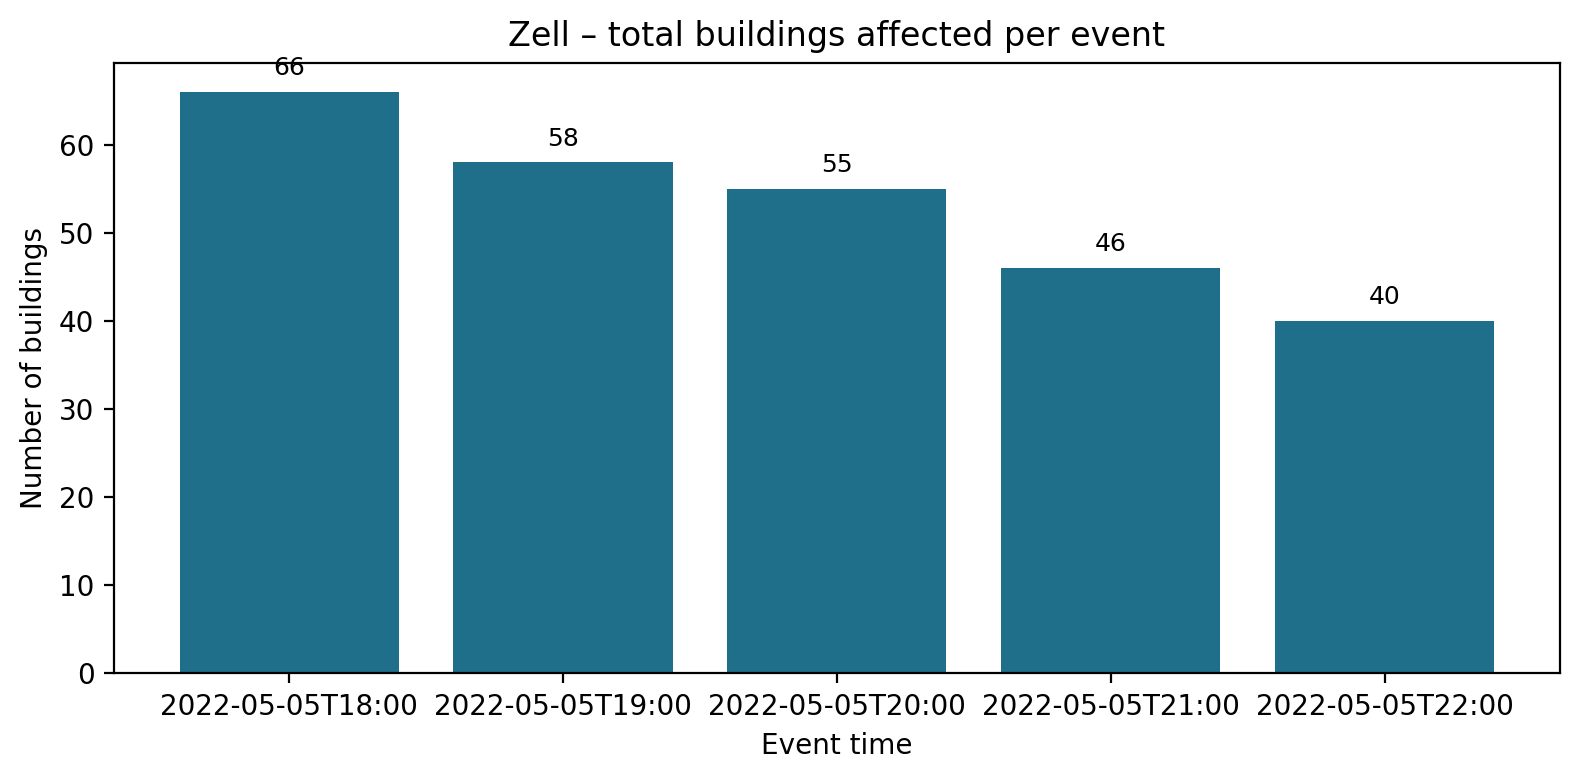

✔ Saved figure to: /home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/total_buildings_per_event.png


In [31]:
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# Total buildings per event_name
# -------------------------------------------------
df_totals = (
    df_counts
    .groupby("event_name", as_index=False)["n_buildings"]
    .sum()
    .sort_values("event_name")
)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), dpi=200)

# ---- TRANSPARENT BACKGROUND ----
fig.patch.set_alpha(0)
ax.set_facecolor((0, 0, 0, 0))

bars = ax.bar(
    df_totals["event_name"],
    df_totals["n_buildings"],
    color="#1f6f8b",
)

# value labels on bars
ymax = df_totals["n_buildings"].max()
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + ymax * 0.02,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xlabel("Event time")
ax.set_ylabel("Number of buildings")
ax.set_title("Zell – total buildings affected per event")

# horizontal ticks
ax.set_xticks(range(len(df_totals)))
ax.set_xticklabels(df_totals["event_name"], rotation=0)

# remove grid
ax.grid(False)

plt.tight_layout()

# -------------------------------------------------
# Save (transparent)
# -------------------------------------------------
outdir = "/home/gespejogutierrez/Lisflood_climada/Zell_Combiprecip_plots/depth_classes/"
os.makedirs(outdir, exist_ok=True)

outfile = os.path.join(outdir, "total_buildings_per_event.png")
plt.savefig(outfile, dpi=300, transparent=True, bbox_inches="tight")

plt.show()

print(f"✔ Saved figure to: {outfile}")


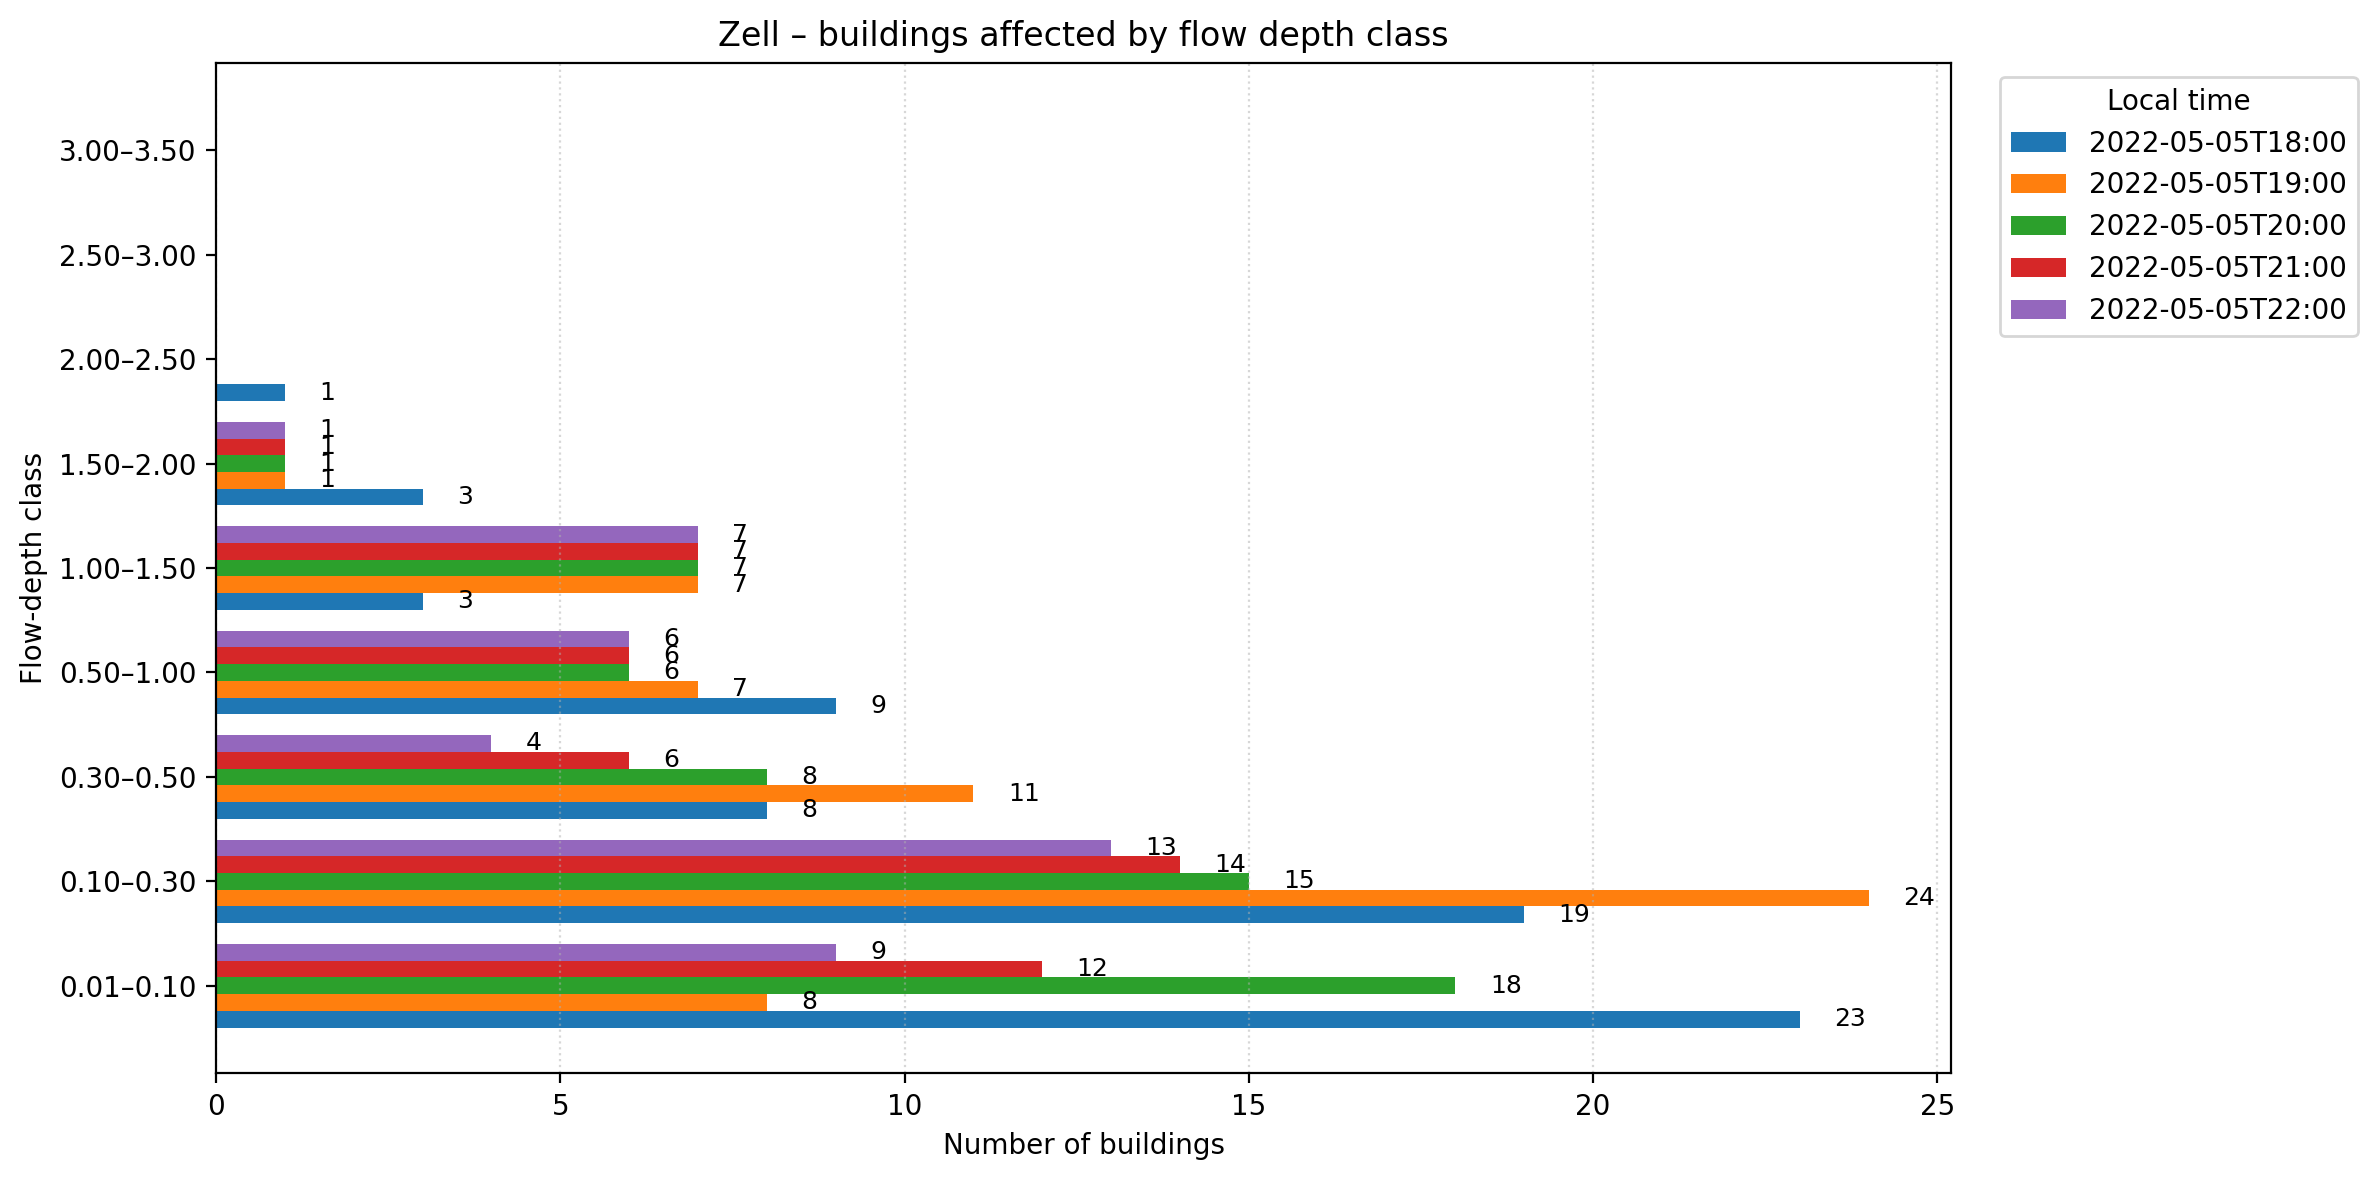

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_depthclass_histogram(df_counts, title="Zell – buildings affected by flow depth class"):
    """
    df_counts must have columns:
      - event_name
      - depth_class
      - n_buildings
    """

    # --- make a wide table: rows=depth_class, cols=event_name ---
    df_wide = (
        df_counts.pivot(index="depth_class", columns="event_name", values="n_buildings")
        .fillna(0)
        .astype(float)
    )

    # Order depth classes (top to bottom like your example)
    # If your depth_class strings differ, edit this list accordingly.
    depth_order = [
        "0.01–0.10", "0.10–0.30", "0.30–0.50", "0.50–1.00",
        "1.00–1.50", "1.50–2.00", "2.00–2.50", "2.50–3.00", "3.00–3.50"
    ]
    # keep only those present (prevents KeyError)
    depth_order = [d for d in depth_order if d in df_wide.index]
    df_wide = df_wide.loc[depth_order]

    # If you want fewer classes like in your screenshot, you can merge before plotting.
    # Otherwise this will plot all depth bins.

    # --- plotting geometry (grouped horizontal bars) ---
    classes = df_wide.index.tolist()
    events  = df_wide.columns.tolist()

    n_cls = len(classes)
    n_evt = len(events)

    y = np.arange(n_cls)
    bar_h = 0.8 / max(n_evt, 1)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=200)

    # plot one barh series per event (Matplotlib default color cycle)
    for i, ev in enumerate(events):
        vals = df_wide[ev].values
        y_pos = y + (i - (n_evt - 1) / 2) * bar_h

        bars = ax.barh(y_pos, vals, height=bar_h, label=str(ev))

        # value labels at bar end
        for b, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    b.get_width() + max(df_wide.values.max() * 0.01, 0.5),
                    b.get_y() + b.get_height() / 2,
                    f"{v:.0f}",
                    va="center",
                    ha="left",
                    fontsize=9,
                )

    # y labels centered
    ax.set_yticks(y)
    ax.set_yticklabels(classes)

    ax.set_xlabel("Number of buildings")
    ax.set_ylabel("Flow-depth class")
    ax.set_title(title)

    ax.grid(axis="x", linestyle=":", alpha=0.5)

    # legend on the right
    ax.legend(title="Local time", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

    plt.tight_layout()
    plt.show()


# --- call it ---
plot_depthclass_histogram(df_counts)
